# Optimal Execution: VWAP, Market Impact & the Almgren-Chriss Framework


---

## Executive Summary

This notebook develops a complete optimal execution framework from first principles. We derive the Almgren-Chriss mean-variance optimization model, implement production-ready execution tools, and discuss extensions used at institutional trading desks.

**Key Deliverables:**
1. VWAP benchmark calculation and schedule generation
2. Market impact models (temporary and permanent)
3. Full derivation of the Almgren-Chriss optimal trajectory
4. Cost-risk frontier analysis
5. Implementation shortfall measurement
6. Discussion of advanced frameworks and research directions

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [VWAP Benchmark](#2-vwap-benchmark)
3. [Market Impact Theory](#3-market-impact-theory)
4. [The Almgren-Chriss Framework](#4-the-almgren-chriss-framework)
5. [Derivation of the Optimal Trajectory](#5-derivation-of-the-optimal-trajectory)
6. [Cost-Risk Frontier Analysis](#6-cost-risk-frontier-analysis)
7. [Lambda Selection and Alpha Decay](#7-lambda-selection-and-alpha-decay)
8. [Implementation Shortfall](#8-implementation-shortfall)
9. [Complete Execution Workflow](#9-complete-execution-workflow)
10. [Extensions and Research Directions](#10-extensions-and-research-directions)
11. [References](#11-references)

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Professional plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.dpi': 100
})

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.precision', 4)

print("Environment configured.")

Environment configured.


## 2. VWAP Benchmark

### 2.1 Definition

The **Volume-Weighted Average Price (VWAP)** over a time period $[0, T]$ is defined as:

$$\text{VWAP} = \frac{\sum_{i=1}^{N} P_i \cdot V_i}{\sum_{i=1}^{N} V_i} = \frac{\int_0^T S(t) \cdot v(t) \, dt}{\int_0^T v(t) \, dt}$$

Where:
- $P_i$ = Price at interval $i$
- $V_i$ = Volume traded at interval $i$
- $S(t)$ = Continuous price process
- $v(t)$ = Volume rate (shares per unit time)

### 2.2 Why VWAP Matters

VWAP serves as a **fair price benchmark** because:

1. **Volume weighting** means prices during high-activity periods contribute more
2. It represents the average price the market paid, not just time-weighted
3. Executing at VWAP means you traded "with the market"

**Important distinction:** VWAP is a *benchmark*, not an *optimization target*. Blindly tracking VWAP can be suboptimal if you have timing constraints or alpha decay.

### 2.3 VWAP Schedule Generation

To track VWAP, we distribute our order proportionally to expected volume:

$$n_k = Q \cdot \frac{V_k}{\sum_{j=1}^{N} V_j}$$

Where:
- $n_k$ = shares to execute in period $k$
- $Q$ = total order size
- $V_k$ = expected volume in period $k$

In [2]:
def calculate_vwap(prices: np.ndarray, volumes: np.ndarray) -> float:
    """
    Calculate Volume-Weighted Average Price.
    
    Parameters
    ----------
    prices : np.ndarray
        Array of prices for each interval
    volumes : np.ndarray
        Array of volumes for each interval
    
    Returns
    -------
    float
        Volume-weighted average price
    """
    if len(prices) != len(volumes):
        raise ValueError("Prices and volumes must have same length")
    if np.sum(volumes) == 0:
        raise ValueError("Total volume cannot be zero")
    
    return np.sum(prices * volumes) / np.sum(volumes)


def generate_vwap_schedule(total_shares: float, volume_profile: np.ndarray) -> np.ndarray:
    """
    Generate execution schedule that tracks VWAP.
    
    Allocates shares proportionally to expected volume in each period.
    
    Parameters
    ----------
    total_shares : float
        Total shares to execute
    volume_profile : np.ndarray
        Expected relative volume in each period (will be normalized)
    
    Returns
    -------
    np.ndarray
        Shares to execute in each period
    """
    weights = volume_profile / np.sum(volume_profile)
    return total_shares * weights

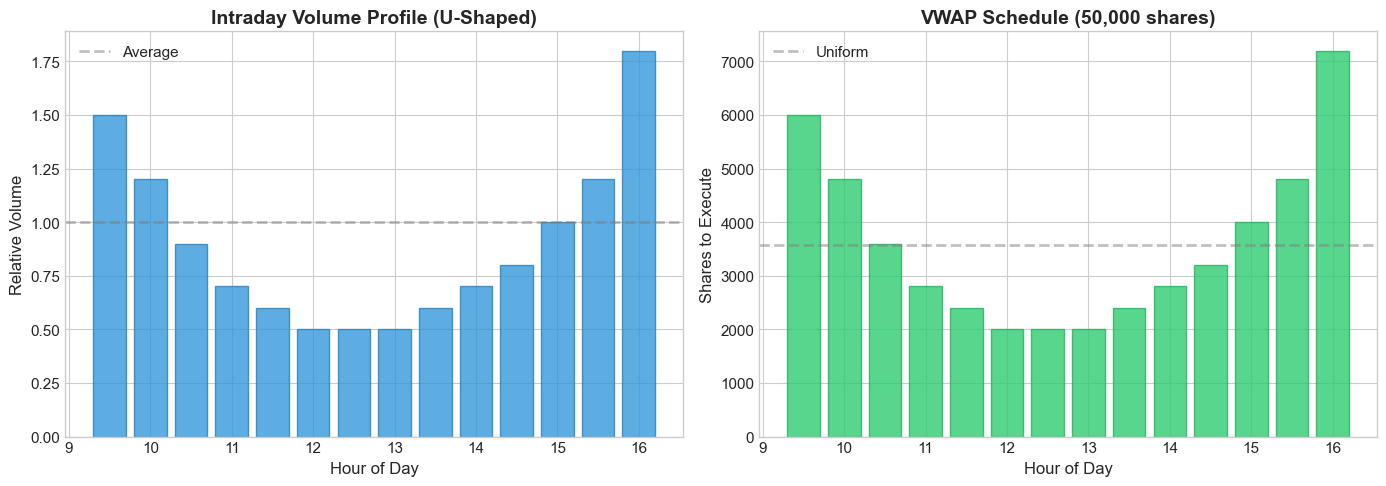

Total shares scheduled: 50,000
Max shares in one period: 7,200 (14.4%)
Min shares in one period: 2,000 (4.0%)


In [3]:
# Typical U-shaped intraday volume profile
# Higher volume at open and close, lower mid-day
hours = np.arange(9.5, 16.5, 0.5)  # 9:30 AM to 4:00 PM
volume_profile = np.array([1.5, 1.2, 0.9, 0.7, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.8])

total_shares = 50000
vwap_schedule = generate_vwap_schedule(total_shares, volume_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hours, volume_profile, width=0.4, color='#3498db', alpha=0.8, edgecolor='#2980b9')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Relative Volume')
axes[0].set_title('Intraday Volume Profile (U-Shaped)', fontweight='bold')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Average')
axes[0].legend()

axes[1].bar(hours, vwap_schedule, width=0.4, color='#2ecc71', alpha=0.8, edgecolor='#27ae60')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Shares to Execute')
axes[1].set_title(f'VWAP Schedule ({int(total_shares):,} shares)', fontweight='bold')
axes[1].axhline(y=total_shares/len(volume_profile), color='gray', linestyle='--', alpha=0.5, label='Uniform')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total shares scheduled: {vwap_schedule.sum():,.0f}")
print(f"Max shares in one period: {vwap_schedule.max():,.0f} ({vwap_schedule.max()/total_shares*100:.1f}%)")
print(f"Min shares in one period: {vwap_schedule.min():,.0f} ({vwap_schedule.min()/total_shares*100:.1f}%)")

## 3. Market Impact Theory

### 3.1 The Fundamental Problem

When you trade, you move the market against yourself:

- **Buying** pushes prices up before you finish buying
- **Selling** pushes prices down before you finish selling

This is **market impact** - the cost of executing in a market with finite liquidity.

### 3.2 Two Types of Impact

#### Temporary Impact

Temporary impact depends on your **trading rate** (shares per unit time) and reverts after execution:

$$\Delta S_{\text{temp}}(t) = \eta \cdot v(t)$$

Where:
- $\eta$ = temporary impact coefficient ($/share per share/time)
- $v(t) = |\dot{x}(t)|$ = absolute trading rate

**Physical interpretation:** Temporary impact reflects the bid-ask spread and the cost of demanding immediate liquidity. When you stop trading, this component dissipates.

#### Permanent Impact

Permanent impact depends on **cumulative volume** and persists indefinitely:

$$\Delta S_{\text{perm}}(t) = \gamma \cdot \left( Q - x(t) \right)$$

Where:
- $\gamma$ = permanent impact coefficient ($/share per share)
- $Q - x(t)$ = cumulative shares already executed by time $t$

**Physical interpretation:** Permanent impact reflects information content of your trading. The market updates its estimate of fair value based on order flow.

### 3.3 Linear Impact Model

The linear impact model (used in Almgren-Chriss) assumes:

$$S(t) = S_0 + \gamma \left( Q - x(t) \right) + \sigma W(t)$$

Where:
- $S_0$ = initial price
- $\sigma$ = volatility
- $W(t)$ = Brownian motion (price randomness independent of our trading)

The execution price at time $t$ when trading at rate $v(t)$ is:

$$\tilde{S}(t) = S(t) + \eta \cdot v(t) = S_0 + \gamma(Q - x(t)) + \eta \cdot v(t) + \sigma W(t)$$

### 3.4 Why Permanent Impact Compounds

Consider executing $Q$ shares in $N$ equal slices of size $n = Q/N$:

| Slice $k$ | Price Paid | Permanent Impact Faced |
|-----------|------------|------------------------|
| 1 | $S_0 + \text{temp}$ | 0 (no prior trades) |
| 2 | $S_0 + \gamma n + \text{temp}$ | $\gamma n$ from slice 1 |
| 3 | $S_0 + 2\gamma n + \text{temp}$ | $2\gamma n$ from slices 1-2 |
| $k$ | $S_0 + (k-1)\gamma n + \text{temp}$ | $(k-1)\gamma n$ |

The total permanent impact cost is:

$$C_{\text{perm}} = \sum_{k=1}^{N} n_k \cdot \gamma \cdot \left( \sum_{j < k} n_j \right) = \gamma \sum_{k=1}^{N} n_k \cdot X_{k-1}$$

Where $X_{k-1} = \sum_{j=1}^{k-1} n_j$ is the cumulative shares executed before slice $k$.

In [4]:
def temporary_impact_cost(schedule: np.ndarray, tau: float, eta: float) -> float:
    """
    Calculate total temporary impact cost.
    
    C_temp = eta * sum(n_k^2 / tau)
    
    Note: n_k/tau is the trading rate in period k.
    
    Parameters
    ----------
    schedule : np.ndarray
        Shares per period
    tau : float
        Time per period
    eta : float
        Temporary impact coefficient
    
    Returns
    -------
    float
        Total temporary impact cost in dollars
    """
    return eta * np.sum(schedule ** 2 / tau)


def permanent_impact_cost(schedule: np.ndarray, gamma: float) -> float:
    """
    Calculate total permanent impact cost.
    
    Each slice k pays permanent impact from all prior slices.
    C_perm = gamma * sum_k (n_k * sum_{j<k} n_j)
    
    Parameters
    ----------
    schedule : np.ndarray
        Shares per period
    gamma : float
        Permanent impact coefficient
    
    Returns
    -------
    float
        Total permanent impact cost in dollars
    """
    cost = 0.0
    cumulative_prior = 0.0
    for n_k in schedule:
        cost += gamma * n_k * cumulative_prior
        cumulative_prior += n_k
    return cost


def total_expected_cost(schedule: np.ndarray, tau: float, gamma: float, eta: float) -> float:
    """
    Calculate total expected execution cost.
    
    E[Cost] = C_perm + C_temp
    """
    return permanent_impact_cost(schedule, gamma) + temporary_impact_cost(schedule, tau, eta)

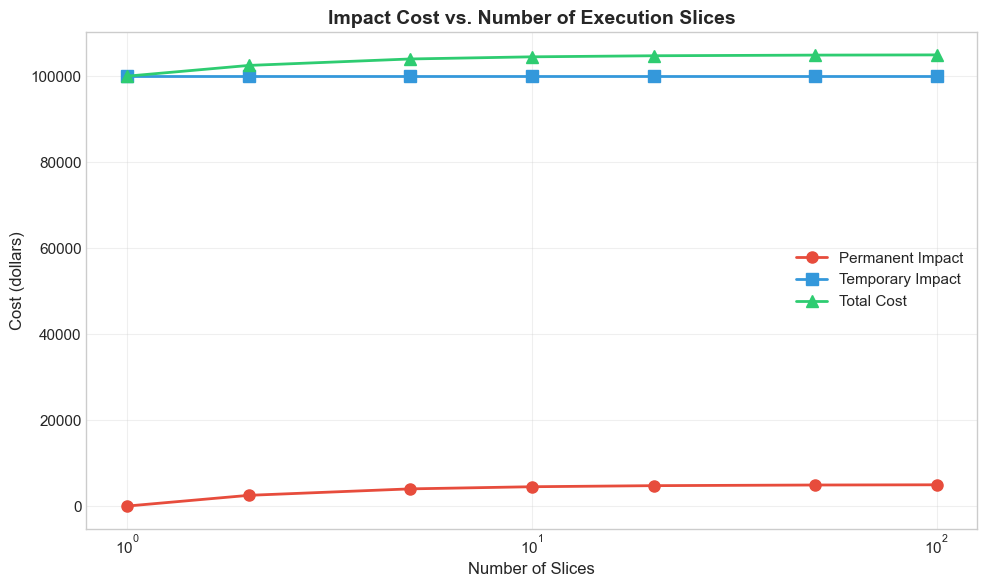

Cost Breakdown by Number of Slices:
N          Permanent       Temporary       Total          
------------------------------------------------------------
1          $0.00           $100000.00      $100000.00     
2          $2500.00        $100000.00      $102500.00     
5          $4000.00        $100000.00      $104000.00     
10         $4500.00        $100000.00      $104500.00     
20         $4750.00        $100000.00      $104750.00     
50         $4900.00        $100000.00      $104900.00     
100        $4950.00        $100000.00      $104950.00     


In [5]:
# Demonstrate impact compounding
Q = 10000
T = 1.0
gamma = 0.0001
eta = 0.001

n_slices_options = [1, 2, 5, 10, 20, 50, 100]
costs_perm = []
costs_temp = []
costs_total = []

for N in n_slices_options:
    tau = T / N
    schedule = np.full(N, Q / N)  # Uniform schedule
    
    c_perm = permanent_impact_cost(schedule, gamma)
    c_temp = temporary_impact_cost(schedule, tau, eta)
    
    costs_perm.append(c_perm)
    costs_temp.append(c_temp)
    costs_total.append(c_perm + c_temp)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_slices_options, costs_perm, 'o-', label='Permanent Impact', color='#e74c3c', linewidth=2, markersize=8)
ax.plot(n_slices_options, costs_temp, 's-', label='Temporary Impact', color='#3498db', linewidth=2, markersize=8)
ax.plot(n_slices_options, costs_total, '^-', label='Total Cost', color='#2ecc71', linewidth=2, markersize=8)

ax.set_xlabel('Number of Slices')
ax.set_ylabel('Cost (dollars)')
ax.set_title('Impact Cost vs. Number of Execution Slices', fontweight='bold')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Cost Breakdown by Number of Slices:")
print("=" * 60)
print(f"{'N':<10} {'Permanent':<15} {'Temporary':<15} {'Total':<15}")
print("-" * 60)
for i, N in enumerate(n_slices_options):
    print(f"{N:<10} ${costs_perm[i]:<14.2f} ${costs_temp[i]:<14.2f} ${costs_total[i]:<14.2f}")

## 4. The Almgren-Chriss Framework

### 4.1 Problem Formulation

We seek the optimal execution trajectory $x(t)$ for $t \in [0, T]$ where:
- $x(t)$ = shares remaining to execute at time $t$
- $x(0) = Q$ (start with full position)
- $x(T) = 0$ (complete by deadline)

The trading rate is $v(t) = -\dot{x}(t) > 0$ (since $x$ is decreasing).

### 4.2 Cost Functional

The total execution cost has three components:

**1. Permanent Impact Cost:**

$$C_{\text{perm}} = \gamma \int_0^T (Q - x(t)) \cdot |\dot{x}(t)| \, dt$$

For continuous execution selling at rate $v(t) = -\dot{x}(t)$, this simplifies to:

$$C_{\text{perm}} = \frac{\gamma}{2} Q^2 - \frac{\gamma}{2} \int_0^T x(t)^2 \cdot (-\ddot{x}(t)/\dot{x}(t)) \, dt \approx \frac{\gamma Q^2}{2}$$

(The permanent impact cost is approximately constant across strategies.)

**2. Temporary Impact Cost:**

$$C_{\text{temp}} = \eta \int_0^T \dot{x}(t)^2 \, dt$$

This is minimized when trading slowly (small $|\dot{x}|$).

**3. Timing Risk (Variance):**

The variance in execution cost due to price fluctuations is:

$$\text{Var}[\text{Cost}] = \sigma^2 \int_0^T x(t)^2 \, dt$$

This is minimized when trading quickly (smaller remaining position $x(t)$).

### 4.3 Mean-Variance Objective

Almgren-Chriss combines expected cost and variance:

$$\min_{x(t)} \quad J[x] = \mathbb{E}[\text{Cost}] + \lambda \cdot \text{Var}[\text{Cost}]$$

$$\min_{x(t)} \quad J[x] = \eta \int_0^T \dot{x}^2 \, dt + \lambda \sigma^2 \int_0^T x^2 \, dt$$

Subject to:
- $x(0) = Q$
- $x(T) = 0$

The parameter $\lambda \geq 0$ is the **risk aversion coefficient**:
- $\lambda = 0$: Risk-neutral (minimize expected cost only)
- $\lambda > 0$: Risk-averse (penalize variance)
- $\lambda \to \infty$: Execute immediately (variance = 0)

## 5. Derivation of the Optimal Trajectory

### 5.1 Euler-Lagrange Equation

The functional to minimize is:

$$J[x] = \int_0^T L(t, x, \dot{x}) \, dt$$

Where the Lagrangian is:

$$L(t, x, \dot{x}) = \eta \dot{x}^2 + \lambda \sigma^2 x^2$$

The Euler-Lagrange equation for extremizing $J$ is:

$$\frac{\partial L}{\partial x} - \frac{d}{dt}\frac{\partial L}{\partial \dot{x}} = 0$$

Computing the partial derivatives:

$$\frac{\partial L}{\partial x} = 2\lambda\sigma^2 x$$

$$\frac{\partial L}{\partial \dot{x}} = 2\eta \dot{x}$$

$$\frac{d}{dt}\frac{\partial L}{\partial \dot{x}} = 2\eta \ddot{x}$$

Substituting into Euler-Lagrange:

$$2\lambda\sigma^2 x - 2\eta \ddot{x} = 0$$

$$\ddot{x} = \frac{\lambda\sigma^2}{\eta} x = \kappa^2 x$$

Where we define:

$$\boxed{\kappa = \sqrt{\frac{\lambda \sigma^2}{\eta}}}$$

### 5.2 General Solution

The ODE $\ddot{x} = \kappa^2 x$ has general solution:

$$x(t) = A e^{\kappa t} + B e^{-\kappa t}$$

Or equivalently in hyperbolic form:

$$x(t) = C \cosh(\kappa t) + D \sinh(\kappa t)$$

### 5.3 Applying Boundary Conditions

**Condition 1:** $x(0) = Q$

$$x(0) = C \cosh(0) + D \sinh(0) = C = Q$$

So $C = Q$.

**Condition 2:** $x(T) = 0$

$$x(T) = Q \cosh(\kappa T) + D \sinh(\kappa T) = 0$$

$$D = -Q \frac{\cosh(\kappa T)}{\sinh(\kappa T)} = -Q \coth(\kappa T)$$

### 5.4 Final Solution

Substituting back:

$$x(t) = Q \cosh(\kappa t) - Q \coth(\kappa T) \sinh(\kappa t)$$

$$x(t) = Q \left[ \cosh(\kappa t) - \frac{\cosh(\kappa T)}{\sinh(\kappa T)} \sinh(\kappa t) \right]$$

$$x(t) = Q \cdot \frac{\sinh(\kappa T)\cosh(\kappa t) - \cosh(\kappa T)\sinh(\kappa t)}{\sinh(\kappa T)}$$

Using the identity $\sinh(A-B) = \sinh A \cosh B - \cosh A \sinh B$:

$$\boxed{x^*(t) = Q \cdot \frac{\sinh(\kappa(T-t))}{\sinh(\kappa T)}}$$

### 5.5 Limiting Cases

**Case 1: $\lambda = 0$ (Risk-Neutral)**

When $\lambda = 0$, we have $\kappa = 0$. Using L'Hopital's rule:

$$\lim_{\kappa \to 0} \frac{\sinh(\kappa(T-t))}{\sinh(\kappa T)} = \frac{T-t}{T}$$

So $x^*(t) = Q(1 - t/T)$, which is **linear execution**.

**Case 2: $\lambda \to \infty$ (Infinitely Risk-Averse)**

As $\kappa \to \infty$:

$$\frac{\sinh(\kappa(T-t))}{\sinh(\kappa T)} \approx e^{-\kappa t} \to 0 \text{ for } t > 0$$

The trajectory approaches a step function: execute everything immediately at $t=0$.

### 5.6 Optimal Trading Rate

The trading rate (shares per unit time) is:

$$v^*(t) = -\dot{x}^*(t) = Q \kappa \cdot \frac{\cosh(\kappa(T-t))}{\sinh(\kappa T)}$$

For $\kappa > 0$, the trading rate is highest at $t=0$ (front-loaded execution).

In [6]:
def optimal_trajectory(Q: float, T: float, N: int, 
                       sigma: float, eta: float, lambda_risk: float) -> Tuple[np.ndarray, float]:
    """
    Generate the Almgren-Chriss optimal execution trajectory.
    
    x*(t) = Q * sinh(kappa * (T - t)) / sinh(kappa * T)
    
    where kappa = sqrt(lambda * sigma^2 / eta)
    
    Parameters
    ----------
    Q : float
        Total shares to execute
    T : float
        Time horizon
    N : int
        Number of time periods
    sigma : float
        Price volatility per unit time
    eta : float
        Temporary impact coefficient
    lambda_risk : float
        Risk aversion parameter (>= 0)
    
    Returns
    -------
    trajectory : np.ndarray
        Shares remaining at each time point [x_0, x_1, ..., x_N]
    kappa : float
        The urgency parameter
    """
    tau = T / N
    t_points = np.arange(N + 1) * tau
    
    # Calculate kappa
    if lambda_risk < 1e-12:
        kappa = 0.0
        # Risk-neutral: linear trajectory
        trajectory = Q * (T - t_points) / T
    else:
        kappa = np.sqrt(lambda_risk * sigma ** 2 / eta)
        # Risk-averse: sinh trajectory
        trajectory = Q * np.sinh(kappa * (T - t_points)) / np.sinh(kappa * T)
    
    return trajectory, kappa


def trajectory_to_schedule(trajectory: np.ndarray) -> np.ndarray:
    """
    Convert shares remaining trajectory to execution schedule.
    
    schedule[k] = x[k] - x[k+1] = shares to execute in period k
    """
    return -np.diff(trajectory)

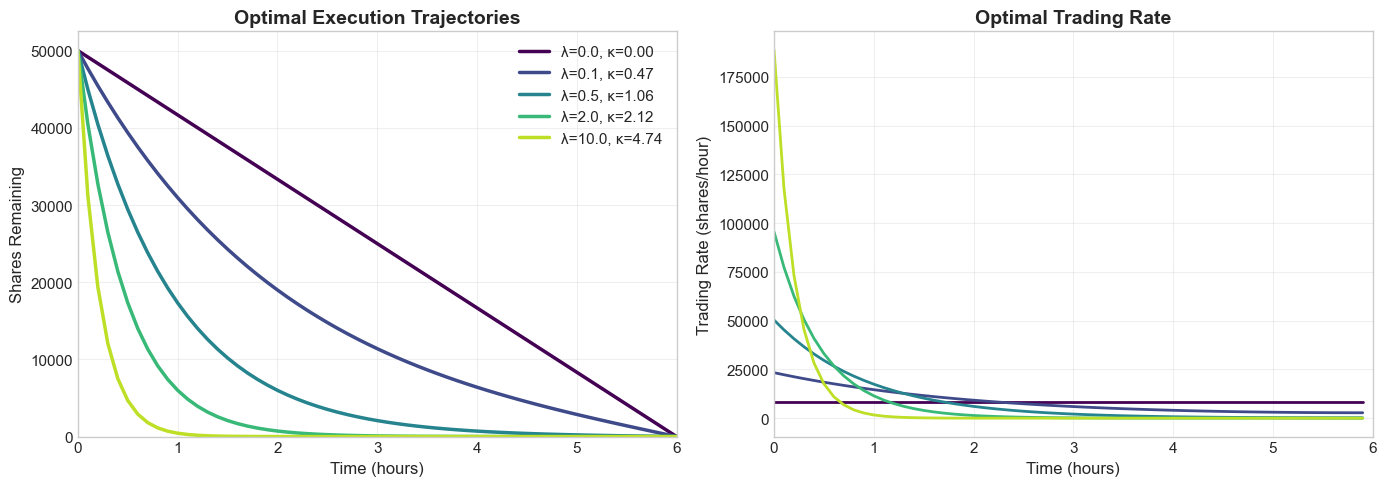

Key Insight: Higher lambda (more risk aversion) -> Higher kappa (more front-loading)


In [7]:
# Visualize optimal trajectories for different lambda values
Q = 50000
T = 6.0
N = 60  # Fine discretization for smooth curves
sigma = 0.015
eta = 0.0001

lambda_values = [0.0, 0.1, 0.5, 2.0, 10.0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(lambda_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lam, color in zip(lambda_values, colors):
    trajectory, kappa = optimal_trajectory(Q, T, N, sigma, eta, lam)
    t_points = np.linspace(0, T, N + 1)
    schedule = trajectory_to_schedule(trajectory)
    
    # Trajectory plot
    axes[0].plot(t_points, trajectory, color=color, linewidth=2.5, 
                 label=f'λ={lam:.1f}, κ={kappa:.2f}')
    
    # Trading rate (normalized)
    tau = T / N
    trading_rate = schedule / tau
    axes[1].plot(t_points[:-1], trading_rate, color=color, linewidth=2)

axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Shares Remaining')
axes[0].set_title('Optimal Execution Trajectories', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, T)
axes[0].set_ylim(0, Q * 1.05)

axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Trading Rate (shares/hour)')
axes[1].set_title('Optimal Trading Rate', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, T)

plt.tight_layout()
plt.show()

print("Key Insight: Higher lambda (more risk aversion) -> Higher kappa (more front-loading)")

## 6. Cost-Risk Frontier Analysis

### 6.1 Computing Expected Cost and Variance

For a given trajectory $x(t)$ discretized to $N$ periods with step $\tau = T/N$:

**Expected Cost:**

$$\mathbb{E}[\text{Cost}] = C_{\text{perm}} + C_{\text{temp}} = \gamma \sum_{k=1}^{N} n_k X_{k-1} + \eta \sum_{k=1}^{N} \frac{n_k^2}{\tau}$$

Where $n_k = x_{k-1} - x_k$ is shares in period $k$ and $X_{k-1} = \sum_{j<k} n_j$ is prior cumulative.

**Variance (Timing Risk):**

$$\text{Var}[\text{Cost}] = \sigma^2 \tau \sum_{k=1}^{N} x_k^2$$

Where $x_k$ is shares remaining at end of period $k$.

### 6.2 The Efficient Frontier

By varying $\lambda$ from 0 to $\infty$, we trace out the **cost-risk efficient frontier**:

- Low $\lambda$: Low expected cost, high variance (slow execution)
- High $\lambda$: High expected cost, low variance (fast execution)

The optimal $\lambda$ depends on your risk tolerance and alpha decay.

In [8]:
def analyze_execution(Q: float, T: float, N: int, sigma: float, 
                      gamma: float, eta: float, lambda_risk: float) -> Dict:
    """
    Complete analysis of an Almgren-Chriss optimal execution.
    
    Returns
    -------
    dict with:
        - trajectory, schedule
        - expected_cost, variance, std_dev
        - objective value
        - kappa
    """
    tau = T / N
    trajectory, kappa = optimal_trajectory(Q, T, N, sigma, eta, lambda_risk)
    schedule = trajectory_to_schedule(trajectory)
    
    # Expected cost
    perm_cost = permanent_impact_cost(schedule, gamma)
    temp_cost = temporary_impact_cost(schedule, tau, eta)
    expected_cost = perm_cost + temp_cost
    
    # Variance
    variance = sigma ** 2 * tau * np.sum(trajectory[1:] ** 2)
    std_dev = np.sqrt(variance)
    
    # Almgren-Chriss objective
    objective = expected_cost + lambda_risk * variance
    
    return {
        'lambda': lambda_risk,
        'kappa': kappa,
        'trajectory': trajectory,
        'schedule': schedule,
        'perm_cost': perm_cost,
        'temp_cost': temp_cost,
        'expected_cost': expected_cost,
        'variance': variance,
        'std_dev': std_dev,
        'objective': objective,
        'first_slice_pct': schedule[0] / Q * 100
    }

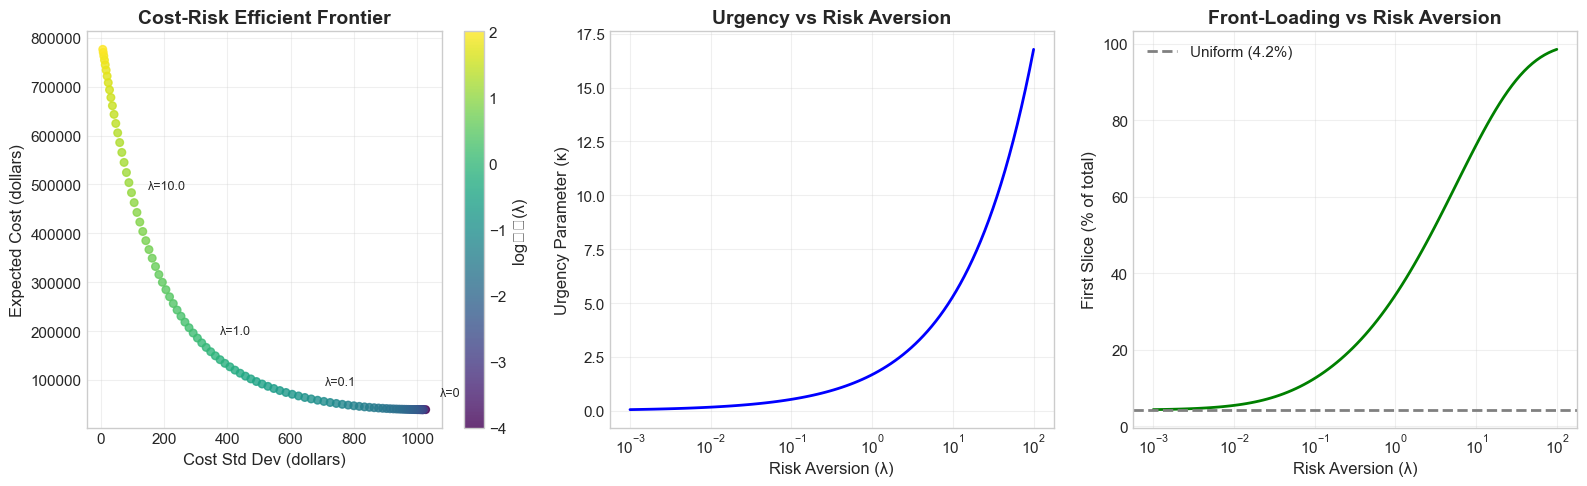

In [9]:
# Generate cost-risk frontier
Q = 50000
T = 6.0
N = 24
sigma = 0.015
gamma = 0.000005
eta = 0.00008

# Logarithmically spaced lambda values
lambda_range = np.concatenate([[0], np.logspace(-3, 2, 100)])
results = [analyze_execution(Q, T, N, sigma, gamma, eta, lam) for lam in lambda_range]

# Extract metrics
expected_costs = np.array([r['expected_cost'] for r in results])
std_devs = np.array([r['std_dev'] for r in results])
kappas = np.array([r['kappa'] for r in results])
lambdas = np.array([r['lambda'] for r in results])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cost-Risk Frontier
scatter = axes[0].scatter(std_devs, expected_costs, c=np.log10(lambdas + 1e-4), 
                          cmap='viridis', s=30, alpha=0.8)
axes[0].set_xlabel('Cost Std Dev (dollars)')
axes[0].set_ylabel('Expected Cost (dollars)')
axes[0].set_title('Cost-Risk Efficient Frontier', fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('log₁₀(λ)')
axes[0].grid(True, alpha=0.3)

# Mark specific points
for lam_mark in [0, 0.1, 1.0, 10.0]:
    idx = np.argmin(np.abs(lambdas - lam_mark))
    axes[0].annotate(f'λ={lam_mark}', (std_devs[idx], expected_costs[idx]),
                     xytext=(10, 10), textcoords='offset points', fontsize=9)

# Kappa vs Lambda
axes[1].plot(lambda_range[1:], kappas[1:], 'b-', linewidth=2)
axes[1].set_xlabel('Risk Aversion (λ)')
axes[1].set_ylabel('Urgency Parameter (κ)')
axes[1].set_title('Urgency vs Risk Aversion', fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

# First slice percentage vs Lambda
first_slices = np.array([r['first_slice_pct'] for r in results])
axes[2].plot(lambda_range[1:], first_slices[1:], 'g-', linewidth=2)
axes[2].axhline(y=100/N, color='gray', linestyle='--', label=f'Uniform ({100/N:.1f}%)')
axes[2].set_xlabel('Risk Aversion (λ)')
axes[2].set_ylabel('First Slice (% of total)')
axes[2].set_title('Front-Loading vs Risk Aversion', fontweight='bold')
axes[2].set_xscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Detailed summary table
sample_lambdas = [0.0, 0.01, 0.1, 0.5, 1.0, 5.0, 20.0]
sample_results = [analyze_execution(Q, T, N, sigma, gamma, eta, lam) for lam in sample_lambdas]

print("Cost-Risk Analysis Summary")
print("=" * 95)
print(f"Order: {Q:,} shares | Horizon: {T} hours | Slices: {N}")
print(f"Parameters: σ={sigma}, γ={gamma}, η={eta}")
print("=" * 95)
print(f"{'λ':<8} {'κ':<8} {'E[Cost]':<14} {'Std Dev':<14} {'Perm':<12} {'Temp':<12} {'1st Slice':<10}")
print("-" * 95)
for r in sample_results:
    print(f"{r['lambda']:<8.2f} {r['kappa']:<8.3f} ${r['expected_cost']:<13.2f} ${r['std_dev']:<13.2f} "
          f"${r['perm_cost']:<11.2f} ${r['temp_cost']:<11.2f} {r['first_slice_pct']:<9.1f}%")

Cost-Risk Analysis Summary
Order: 50,000 shares | Horizon: 6.0 hours | Slices: 24
Parameters: σ=0.015, γ=5e-06, η=8e-05
λ        κ        E[Cost]        Std Dev        Perm         Temp         1st Slice 
-----------------------------------------------------------------------------------------------
0.00     0.000    $39322.92      $1027.46       $5989.58     $33333.33    4.2      %
0.01     0.168    $39949.01      $960.96        $5984.65     $33964.36    5.4      %
0.10     0.530    $60132.37      $673.27        $5825.73     $54306.64    12.5     %
0.50     1.186    $123057.09     $416.85        $5330.26     $117726.83   25.7     %
1.00     1.677    $170249.59     $327.27        $4958.66     $165290.92   34.2     %
5.00     3.750    $353268.60     $159.60        $3517.57     $349751.03   60.8     %
20.00    7.500    $588919.27     $58.20         $1662.05     $587257.22   84.7     %


## 7. Lambda Selection and Alpha Decay

### 7.1 The Key Insight

**Lambda should match your alpha decay rate.**

If you're trading because you have a signal (alpha), that signal decays over time. The faster it decays, the more urgently you need to execute.

### 7.2 Matching Kappa to Half-Life

If your alpha has **half-life** $h$ (time for signal to lose half its value), you want to complete most execution within that time.

The Almgren-Chriss trajectory has characteristic time scale $1/\kappa$. Setting:

$$\kappa \approx \frac{1}{h}$$

Ensures you execute with urgency matched to signal decay.

### 7.3 Deriving Lambda from Half-Life

Given $\kappa = \sqrt{\lambda \sigma^2 / \eta}$, solving for $\lambda$:

$$\lambda = \frac{\kappa^2 \eta}{\sigma^2} = \frac{\eta}{h^2 \sigma^2}$$

### 7.4 Practical Guidelines

**Momentum signals** (half-life: minutes to hours): High lambda (1-10)

**Mean reversion** (half-life: hours to days): Moderate lambda (0.1-1)

**Value/Rebalancing** (half-life: days to weeks): Low lambda (0.01-0.1)

**Index rebalancing** (known date, no alpha): Very low lambda (~0)

In [11]:
def suggest_lambda(alpha_halflife: float, sigma: float, eta: float) -> float:
    """
    Suggest lambda based on alpha decay rate.
    
    Target: kappa ≈ 1/halflife
    Therefore: lambda = eta / (halflife^2 * sigma^2)
    
    Parameters
    ----------
    alpha_halflife : float
        Time for alpha signal to decay by half
    sigma : float
        Price volatility per unit time
    eta : float
        Temporary impact coefficient
    
    Returns
    -------
    float
        Suggested lambda value
    """
    target_kappa = 1.0 / alpha_halflife
    return (target_kappa ** 2) * eta / (sigma ** 2)

In [12]:
# Lambda recommendations for different scenarios
scenarios = [
    {'name': 'HFT Signal', 'halflife': 0.1, 'desc': '6 minutes'},
    {'name': 'Momentum', 'halflife': 0.5, 'desc': '30 minutes'},
    {'name': 'Intraday Alpha', 'halflife': 2.0, 'desc': '2 hours'},
    {'name': 'Mean Reversion', 'halflife': 8.0, 'desc': '1 trading day'},
    {'name': 'Value Signal', 'halflife': 40.0, 'desc': '1 week'},
    {'name': 'Index Rebalance', 'halflife': 200.0, 'desc': '1 month'},
]

print("Lambda Recommendations by Trading Scenario")
print("=" * 85)
print(f"{'Scenario':<20} {'Half-life':<15} {'λ':<12} {'κ':<10} {'Strategy':<20}")
print("-" * 85)

for s in scenarios:
    lam = suggest_lambda(s['halflife'], sigma, eta)
    kappa = np.sqrt(lam * sigma ** 2 / eta) if lam > 0 else 0
    
    if lam > 5:
        strategy = 'Very Aggressive'
    elif lam > 1:
        strategy = 'Aggressive'
    elif lam > 0.1:
        strategy = 'Moderate'
    else:
        strategy = 'Passive'
    
    print(f"{s['name']:<20} {s['desc']:<15} {lam:<12.4f} {kappa:<10.3f} {strategy:<20}")

Lambda Recommendations by Trading Scenario
Scenario             Half-life       λ            κ          Strategy            
-------------------------------------------------------------------------------------
HFT Signal           6 minutes       35.5556      10.000     Very Aggressive     
Momentum             30 minutes      1.4222       2.000      Aggressive          
Intraday Alpha       2 hours         0.0889       0.500      Passive             
Mean Reversion       1 trading day   0.0056       0.125      Passive             
Value Signal         1 week          0.0002       0.025      Passive             
Index Rebalance      1 month         0.0000       0.005      Passive             


## 8. Implementation Shortfall

### 8.1 Definition

**Implementation Shortfall (IS)** measures the difference between your execution price and your decision price:

$$\text{IS} = \text{VWAP}_{\text{execution}} - S_{\text{decision}}$$

Where:
- $\text{VWAP}_{\text{execution}}$ = volume-weighted average of all your fills
- $S_{\text{decision}}$ = price when you decided to trade

### 8.2 Interpretation

For a **buy order**:
- IS > 0: You paid more than the decision price (bad)
- IS < 0: You paid less than the decision price (good)

For a **sell order**, flip the interpretation.

### 8.3 Components of IS

IS captures the total cost of execution:

1. **Market Impact**: Your trading moved the price
2. **Timing Cost**: Price drifted while you were executing
3. **Alpha Decay**: Signal lost value during execution

### 8.4 Using IS for Calibration

Compare realized IS to expected cost:
- **IS ≈ E[Cost]**: Impact estimates are accurate
- **IS >> E[Cost]**: Underestimated impact or unlucky timing
- **IS << E[Cost]**: Overestimated impact or lucky timing

Use this feedback to calibrate $\gamma$ and $\eta$ over time.

In [13]:
def implementation_shortfall(execution_prices: np.ndarray, 
                             execution_shares: np.ndarray, 
                             decision_price: float) -> Dict:
    """
    Calculate implementation shortfall from execution data.
    
    Parameters
    ----------
    execution_prices : np.ndarray
        Price of each fill
    execution_shares : np.ndarray
        Shares in each fill
    decision_price : float
        Price when trade decision was made
    
    Returns
    -------
    dict with:
        - vwap: execution VWAP
        - is_per_share: IS in dollars per share
        - is_total: total IS in dollars
        - is_bps: IS in basis points
    """
    total_shares = np.sum(execution_shares)
    vwap = np.sum(execution_prices * execution_shares) / total_shares
    
    is_per_share = vwap - decision_price
    is_total = is_per_share * total_shares
    is_bps = (is_per_share / decision_price) * 10000
    
    return {
        'vwap': vwap,
        'decision_price': decision_price,
        'is_per_share': is_per_share,
        'is_total': is_total,
        'is_bps': is_bps,
        'total_shares': total_shares
    }

## 9. Complete Execution Workflow

We now demonstrate the full workflow: pre-trade analysis → execution → post-trade evaluation.

In [14]:
def run_execution_simulation(order: Dict, market: Dict, alpha_halflife: float, 
                              seed: int = None) -> Dict:
    """
    Simulate complete execution workflow.
    
    1. Pre-trade: Estimate costs, choose lambda
    2. Execute: Simulate with price evolution
    3. Post-trade: Calculate IS, compare to expected
    
    Parameters
    ----------
    order : dict
        shares, horizon, slices, decision_price
    market : dict
        sigma, gamma, eta
    alpha_halflife : float
        Half-life of alpha signal in same units as horizon
    seed : int, optional
        Random seed for reproducibility
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Unpack parameters
    Q = order['shares']
    T = order['horizon']
    N = order['slices']
    decision_price = order['decision_price']
    sigma = market['sigma']
    gamma = market['gamma']
    eta = market['eta']
    tau = T / N
    
    # ========== PRE-TRADE ==========
    lambda_risk = suggest_lambda(alpha_halflife, sigma, eta)
    pre_trade = analyze_execution(Q, T, N, sigma, gamma, eta, lambda_risk)
    
    # ========== EXECUTE ==========
    schedule = pre_trade['schedule']
    execution_prices = []
    price_path = [decision_price]
    
    current_price = decision_price
    for shares in schedule:
        # Permanent impact
        current_price += gamma * shares
        # Random price movement
        current_price += sigma * np.sqrt(tau) * np.random.randn() * current_price / 100
        # Fill price includes temporary impact
        fill_price = current_price + eta * (shares / tau)
        
        execution_prices.append(fill_price)
        price_path.append(current_price)
    
    execution_prices = np.array(execution_prices)
    
    # ========== POST-TRADE ==========
    is_result = implementation_shortfall(execution_prices, schedule, decision_price)
    
    return {
        'order': order,
        'market': market,
        'alpha_halflife': alpha_halflife,
        'lambda': lambda_risk,
        'pre_trade': pre_trade,
        'execution_prices': execution_prices,
        'price_path': np.array(price_path),
        'is_result': is_result
    }

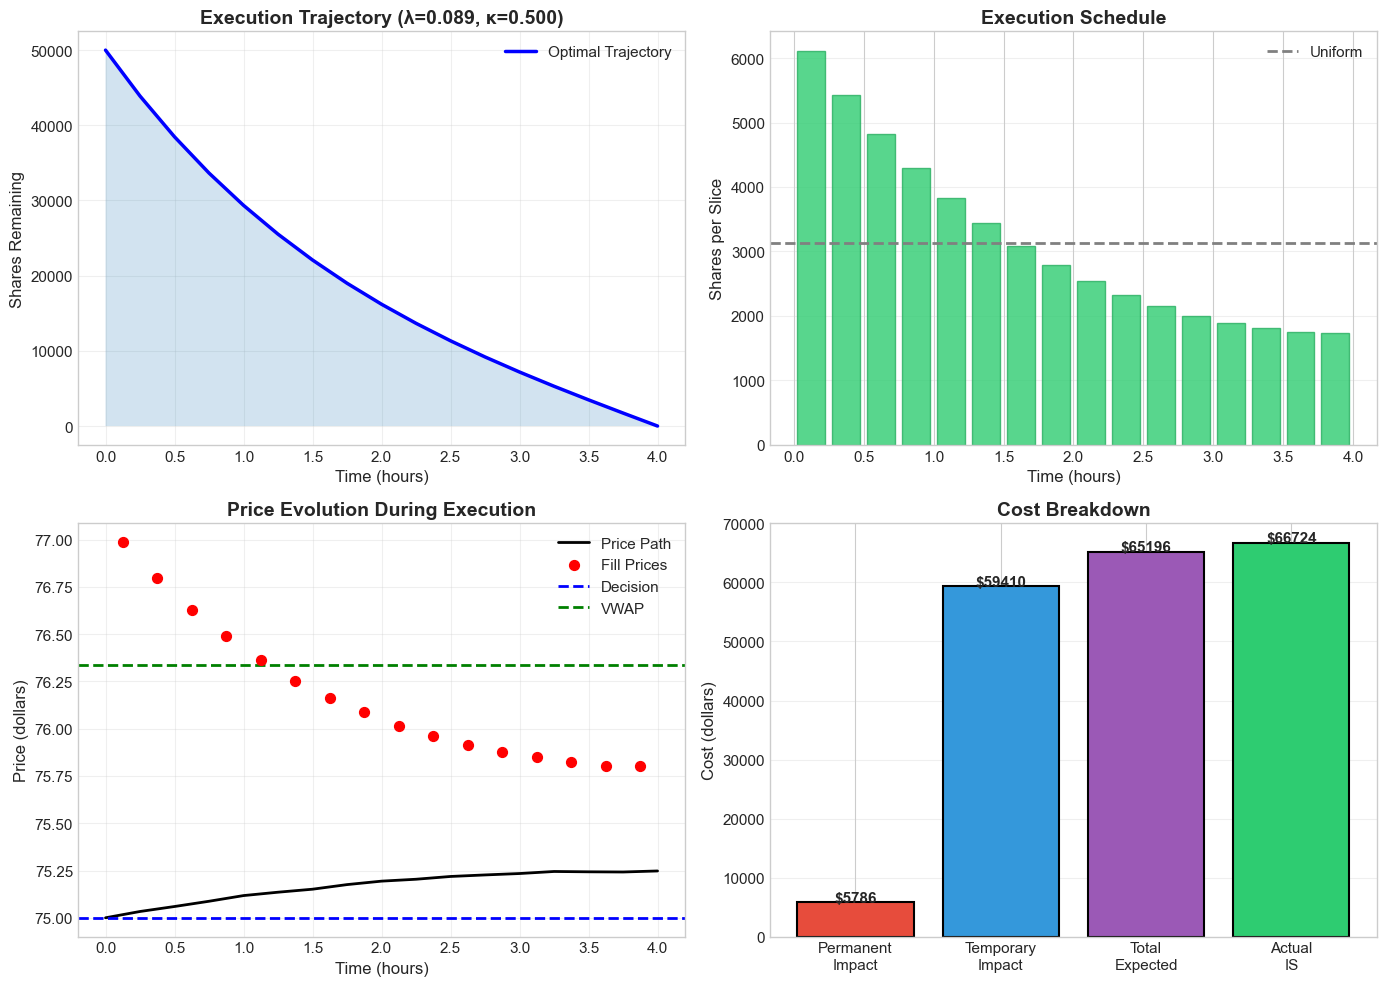

In [15]:
# Example: Momentum signal execution
order = {
    'shares': 50000,
    'horizon': 4.0,
    'slices': 16,
    'decision_price': 75.00
}

market = {
    'sigma': 0.015,
    'gamma': 0.000005,
    'eta': 0.00008
}

result = run_execution_simulation(order, market, alpha_halflife=2.0, seed=42)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pre_trade = result['pre_trade']
t_points = np.linspace(0, order['horizon'], order['slices'] + 1)
tau = order['horizon'] / order['slices']

# Trajectory
axes[0, 0].plot(t_points, pre_trade['trajectory'], 'b-', linewidth=2.5, label='Optimal Trajectory')
axes[0, 0].fill_between(t_points, 0, pre_trade['trajectory'], alpha=0.2)
axes[0, 0].set_xlabel('Time (hours)')
axes[0, 0].set_ylabel('Shares Remaining')
axes[0, 0].set_title(f'Execution Trajectory (λ={result["lambda"]:.3f}, κ={pre_trade["kappa"]:.3f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Schedule
slice_times = t_points[:-1] + tau/2
axes[0, 1].bar(slice_times, pre_trade['schedule'], width=tau*0.8, color='#2ecc71', alpha=0.8, edgecolor='#27ae60')
axes[0, 1].axhline(y=order['shares']/order['slices'], color='gray', linestyle='--', label='Uniform')
axes[0, 1].set_xlabel('Time (hours)')
axes[0, 1].set_ylabel('Shares per Slice')
axes[0, 1].set_title('Execution Schedule', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Price path
axes[1, 0].plot(t_points, result['price_path'], 'k-', linewidth=2, label='Price Path')
axes[1, 0].scatter(slice_times, result['execution_prices'], c='red', s=50, zorder=5, label='Fill Prices')
axes[1, 0].axhline(y=order['decision_price'], color='blue', linestyle='--', label='Decision')
axes[1, 0].axhline(y=result['is_result']['vwap'], color='green', linestyle='--', label='VWAP')
axes[1, 0].set_xlabel('Time (hours)')
axes[1, 0].set_ylabel('Price (dollars)')
axes[1, 0].set_title('Price Evolution During Execution', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Cost breakdown
labels = ['Permanent\nImpact', 'Temporary\nImpact', 'Total\nExpected', 'Actual\nIS']
values = [pre_trade['perm_cost'], pre_trade['temp_cost'], pre_trade['expected_cost'], result['is_result']['is_total']]
colors = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71']
axes[1, 1].bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Cost (dollars)')
axes[1, 1].set_title('Cost Breakdown', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(values):
    axes[1, 1].text(i, v + 50, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# Execution Summary Report
print("=" * 70)
print("EXECUTION SUMMARY REPORT")
print("=" * 70)

print("\n--- ORDER DETAILS ---")
print(f"Shares:           {order['shares']:,}")
print(f"Horizon:          {order['horizon']} hours")
print(f"Slices:           {order['slices']}")
print(f"Decision Price:   ${order['decision_price']:.2f}")

print("\n--- PRE-TRADE ANALYSIS ---")
print(f"Alpha Half-life:  {result['alpha_halflife']} hours")
print(f"Suggested λ:      {result['lambda']:.4f}")
print(f"Urgency κ:        {pre_trade['kappa']:.4f}")
print(f"Expected Cost:    ${pre_trade['expected_cost']:.2f}")
print(f"  - Permanent:    ${pre_trade['perm_cost']:.2f}")
print(f"  - Temporary:    ${pre_trade['temp_cost']:.2f}")
print(f"Cost Std Dev:     ${pre_trade['std_dev']:.2f}")
print(f"First Slice:      {pre_trade['first_slice_pct']:.1f}% of total")

print("\n--- POST-TRADE ANALYSIS ---")
is_r = result['is_result']
print(f"Execution VWAP:   ${is_r['vwap']:.4f}")
print(f"IS per share:     ${is_r['is_per_share']:.4f} ({is_r['is_bps']:.1f} bps)")
print(f"Total IS:         ${is_r['is_total']:.2f}")

print("\n--- ASSESSMENT ---")
ratio = is_r['is_total'] / pre_trade['expected_cost'] if pre_trade['expected_cost'] > 0 else 0
if abs(ratio - 1) < 0.25:
    assessment = "GOOD: Actual cost within 25% of expected"
elif ratio < 0.75:
    assessment = "EXCELLENT: Beat expectations significantly"
else:
    assessment = "REVIEW: Cost exceeded expectations"
print(f"IS / E[Cost]:     {ratio:.2f}x")
print(f"Assessment:       {assessment}")
print("=" * 70)

EXECUTION SUMMARY REPORT

--- ORDER DETAILS ---
Shares:           50,000
Horizon:          4.0 hours
Slices:           16
Decision Price:   $75.00

--- PRE-TRADE ANALYSIS ---
Alpha Half-life:  2.0 hours
Suggested λ:      0.0889
Urgency κ:        0.5000
Expected Cost:    $65196.25
  - Permanent:    $5785.86
  - Temporary:    $59410.39
Cost Std Dev:     $656.27
First Slice:      12.2% of total

--- POST-TRADE ANALYSIS ---
Execution VWAP:   $76.3345
IS per share:     $1.3345 (177.9 bps)
Total IS:         $66723.93

--- ASSESSMENT ---
IS / E[Cost]:     1.02x
Assessment:       GOOD: Actual cost within 25% of expected


## 10. Extensions and Research Directions

The Almgren-Chriss framework is the **foundation** of optimal execution theory, but production systems at top quantitative firms extend it in several important directions. This section outlines the key extensions and provides references for further study.

---

### 10.1 Transient Impact Models

**Limitation of Almgren-Chriss:** The model assumes impact is either purely temporary (reverts instantly) or purely permanent (never decays). In reality, impact decays gradually.

**Obizhaeva-Wang (2013)** introduced a "block-shaped" limit order book model where impact decays exponentially with resilience parameter $\rho$:

$$\Delta S(t) = \int_0^t e^{-\rho(t-s)} \cdot dQ(s)$$

**Gatheral-Schied (2011)** generalized this to arbitrary decay kernels $G(t)$:

$$S(t) = S_0 + \int_0^t G(t-s) \cdot \dot{x}(s) \, ds$$

These models capture the realistic observation that large trades impact prices for minutes to hours before the order book refills.

**Key paper:** Gatheral, Schied, Slynko (2012). "Transient Linear Price Impact and Fredholm Integral Equations"

---

### 10.2 Stochastic Control Approach

**Limitation of Almgren-Chriss:** The framework solves for a deterministic trajectory. It doesn't adapt to incoming information during execution.

**Cartea-Jaimungal** reformulate optimal execution as a stochastic control problem. The trader solves a **Hamilton-Jacobi-Bellman (HJB) equation** for the value function:

$$\partial_t V + \sup_{v} \left[ \mathcal{L}V - \ell(v) \right] = 0$$

Where $v$ is the trading rate, $\mathcal{L}$ is the infinitesimal generator of the price process, and $\ell(v)$ is the running cost.

This yields **adaptive policies** that respond to price movements, volume patterns, and other market signals in real-time.

**Key textbook:** Cartea, Jaimungal, Penalva (2015). "Algorithmic and High-Frequency Trading"

---

### 10.3 Limit Order Execution

**Limitation of Almgren-Chriss:** The model assumes you execute via market orders only. Real execution uses a mix of limit and market orders.

Limit orders add:
- **Fill uncertainty**: Your order may not execute
- **Queue position dynamics**: Earlier orders get filled first
- **Adverse selection**: You're more likely to be filled when it's disadvantageous

**Guéant-Lehalle-Fernandez-Tapia** model the optimal posting strategy for limit orders:

$$\delta^*(t, q) = \frac{1}{\gamma} + \frac{2q + 1}{2} \cdot \Gamma \cdot (T - t)$$

Where $\delta$ is the distance from midprice, $q$ is inventory, and $\Gamma$ measures adverse selection.

**Key paper:** Guéant, Lehalle, Fernandez-Tapia (2012). "Dealing with the Inventory Risk"

---

### 10.4 Multi-Asset Execution

**Limitation:** The single-asset model ignores correlations between assets.

When executing a portfolio, you must consider:
- **Cross-impact**: Trading Asset A affects Asset B's price
- **Portfolio risk**: Variance depends on the covariance matrix
- **Optimal sequencing**: Which assets to trade first

The multi-asset Almgren-Chriss problem has matrix-valued impact parameters:

$$\min_{X(t)} \quad \text{tr}\left( \eta \int_0^T \dot{X}^\top \dot{X} \, dt \right) + \lambda \cdot \text{tr}\left( \Sigma \int_0^T X^\top X \, dt \right)$$

**Key paper:** Almgren, Chriss (2000). "Optimal Execution of Portfolio Transactions" (original paper covers multi-asset case)

---

### 10.5 Reinforcement Learning

**Modern approach:** Rather than assuming parametric impact models, learn optimal policies directly from data.

**Deep RL for execution:**
- State: Current inventory, time remaining, recent price/volume
- Action: Shares to trade this period
- Reward: Negative implementation shortfall

Advantages:
- Captures nonlinear effects
- Adapts to regime changes
- Can incorporate alternative data

Challenges:
- Sample efficiency (execution is expensive)
- Simulation-to-reality gap
- Interpretability

**Key paper:** Ning, Treichler, Chen (2021). "Double Deep Q-Learning for Optimal Execution"

---

### 10.6 Suggested Reading Path

For practitioners wanting to go deeper:

1. **Start here:** Almgren & Chriss (2000) - "Optimal Execution of Portfolio Transactions"
2. **Transient impact:** Gatheral (2010) - "No-Dynamic-Arbitrage and Market Impact"
3. **Stochastic control:** Cartea & Jaimungal (2015) - "Algorithmic and High-Frequency Trading" (textbook)
4. **Limit orders:** Guéant (2016) - "The Financial Mathematics of Market Liquidity" (textbook)
5. **Empirical:** Almgren et al. (2005) - "Direct Estimation of Equity Market Impact"

---

### 10.7 Practical Next Steps

To extend this project:

1. **Calibrate to real data:** Estimate $\gamma$ and $\eta$ from your own execution data
2. **Add transient decay:** Implement Obizhaeva-Wang model with exponential decay
3. **Backtest:** Simulate execution on historical tick data
4. **Adaptive execution:** Implement simple feedback rules (speed up if behind, slow down if ahead)
5. **Multi-asset:** Extend to portfolio execution with cross-impact

## 11. References

### Foundational Papers

1. Almgren, R., & Chriss, N. (2000). **Optimal Execution of Portfolio Transactions.** *Journal of Risk*, 3(2), 5-39.

2. Almgren, R. (2003). **Optimal Execution with Nonlinear Impact Functions and Trading-Enhanced Risk.** *Applied Mathematical Finance*, 10(1), 1-18.

3. Almgren, R., Thum, C., Hauptmann, E., & Li, H. (2005). **Direct Estimation of Equity Market Impact.** *Risk*, 18(7), 58-62.

### Transient Impact

4. Gatheral, J. (2010). **No-Dynamic-Arbitrage and Market Impact.** *Quantitative Finance*, 10(7), 749-759.

5. Gatheral, J., Schied, A., & Slynko, A. (2012). **Transient Linear Price Impact and Fredholm Integral Equations.** *Mathematical Finance*, 22(3), 445-474.

6. Obizhaeva, A. A., & Wang, J. (2013). **Optimal Trading Strategy and Supply/Demand Dynamics.** *Journal of Financial Markets*, 16(1), 1-32.

### Stochastic Control

7. Cartea, Á., & Jaimungal, S. (2015). **Optimal Execution with Limit and Market Orders.** *Quantitative Finance*, 15(8), 1279-1291.

8. Cartea, Á., Jaimungal, S., & Penalva, J. (2015). **Algorithmic and High-Frequency Trading.** Cambridge University Press.

### Limit Orders

9. Guéant, O., Lehalle, C. A., & Fernandez-Tapia, J. (2012). **Dealing with the Inventory Risk: A Solution to the Market Making Problem.** *Mathematics and Financial Economics*, 7(4), 477-507.

10. Guéant, O. (2016). **The Financial Mathematics of Market Liquidity.** Chapman and Hall/CRC.

### Modern Approaches

11. Ning, B., Treichler, D., & Chen, S. (2021). **Double Deep Q-Learning for Optimal Execution.** *Applied Mathematical Finance*, 28(4), 361-380.

---

*This notebook was created as part of the QuantFrame educational platform: [quantframe.io](https://quantframe.io)*